<a href="https://colab.research.google.com/github/arshdee17/Medical-Insurance-Forecast./blob/main/Insurance_Forecaset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
#read csv
url = "https://raw.githubusercontent.com/arshdee17/Medical-Insurance-Forecast./main/insurance.csv"
df = pd.read_csv(url)
display(df.head())


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [20]:
#data cleaning
df = df.drop_duplicates()
# Convert categorical variables to dummy/indicator variables
df_encoded = pd.get_dummies(df, drop_first=True)
#log transformation
df_encoded['log_charges'] = np.log1p(df_encoded['charges'])

The quality check confirmed 1,338 records with zero missing values, while one duplicate entry was removed to maintain data integrity. I applied a log transformation to the charges variable to correct its significant right-skew, resulting in a more normalized distribution that better aligns with the assumptions of linear regression

/tmp/ipykernel_11958/181499760.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


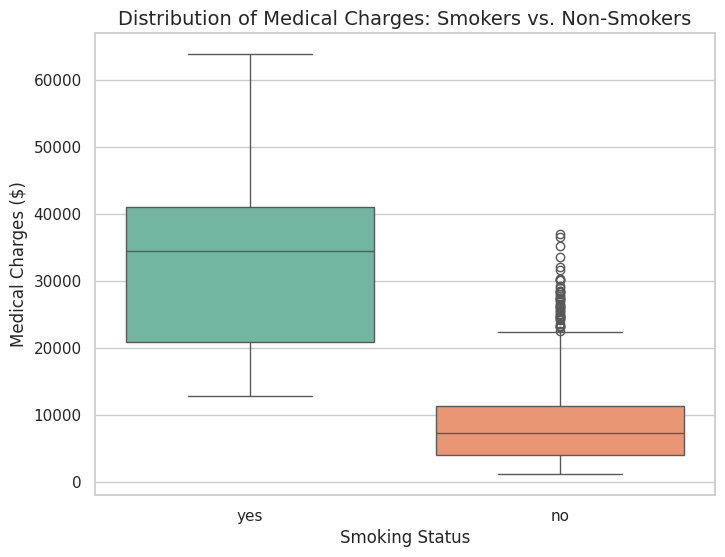

In [27]:
#explanatory analysis 1
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')

plt.title('Distribution of Medical Charges: Smokers vs. Non-Smokers', fontsize=14)
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Medical Charges ($)', fontsize=12)

plt.show()

Rationale: I selected a Box Plot to compare medical charges between smokers and non-smokers because it allows for an immediate comparison of the central tendency (median) and the spread (variance) of costs between these two key groups. This visualization is essential for identifying whether a categorical variable like smoker creates a distinct gap in the target variable like charges, which helps justify its inclusion as a primary feature in the regression model.

Interpretation:The plot reveals a dramatic disparity in medical costs: the median charge for smokers is approximately $35,000, which is significantly higher than even the most extreme outliers in the non-smoker group. Furthermore, the "smoker" category shows much higher variance (a taller box), suggesting that while smoking universally increases costs, it also makes those costs more volatile and harder to predict.

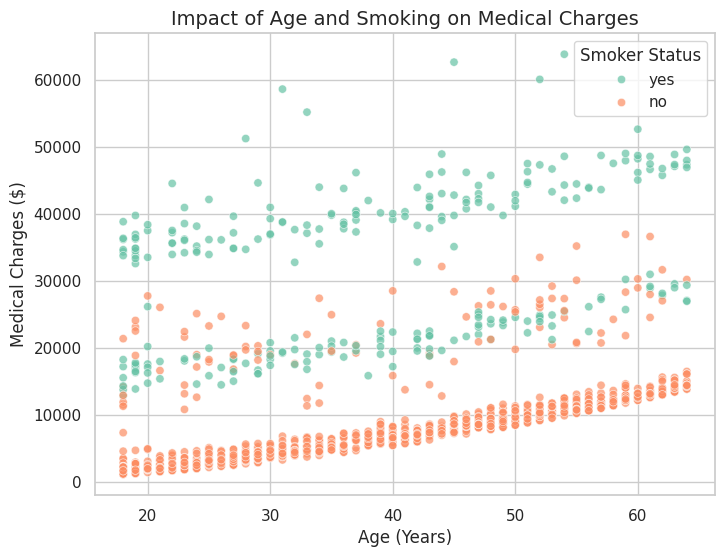

In [29]:
##explanatory analysis 2
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='Set2', alpha=0.7)

plt.title('Impact of Age and Smoking on Medical Charges', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Medical Charges ($)', fontsize=12)
plt.legend(title='Smoker Status')

plt.show()

Rationale: I selected a Scatter Plot with color-coded markers to analyze the simultaneous impact of a continuous numerical variable (age) and a categorical variable (smoker) on medical charges. This visualization is essential for determining if the relationship between age and cost is linear and identifying how lifestyle factors create distinct cost "bands" within the population.

Interpretation: The scatter plot illustrates that while medical charges increase linearly with age for all groups, smoking status acts as a massive vertical shifter that creates three distinct cost tiers of varying financial risk. The consistent upward slope across these "cost bands" justifies using Multiple Linear Regression, as age serves as a stable baseline driver of cost regardless of lifestyle category

In [10]:
#define features
X = df_encoded.drop(['charges', 'log_charges'], axis=1)
y = df_encoded['log_charges']

In [11]:
#train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Multiple Linear Regression (MLR) is the most appropriate technique for this dataset because it balances predictive power with the high level of transparency required in an insurance and business context. Knowing exactly "why" a premium is high—such as the specific cost added per year of age or for smoking status—is as important as the final price itself.

The key reasons MLR is the best fit for this data include:
* Linear Trends: Exploratory visualizations show that medical charges increase at a relatively consistent, linear rate as a patient ages.
* Quantifiable Impact: MLR provides clear coefficients for each feature, allowing stakeholders to see that being a smoker, for example, acts as a massive "vertical shifter" or multiplier on total costs.
* Explainable AI: Unlike "black box" models, MLR allows an insurance company to justify rate increases to customers or regulators by citing specific independent variables like BMI or geographic region.
* Target Normalization: By using a Log Transformation on the charges, the model effectively handles the right-skewed nature of medical costs, making the relationship more linear and the mathematical assumptions of the model more stable.

In [13]:
#test
y_pred = model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")

Model R2 Score: 0.8295


The Multiple Linear Regression model achieved an R² score of 0.8295, meaning it explains approximately 83% of the variance in medical charges. By applying a log transformation to the target variable, the model successfully normalized the right-skewed cost distribution and provided stable, interpretable coefficients for each risk factor.

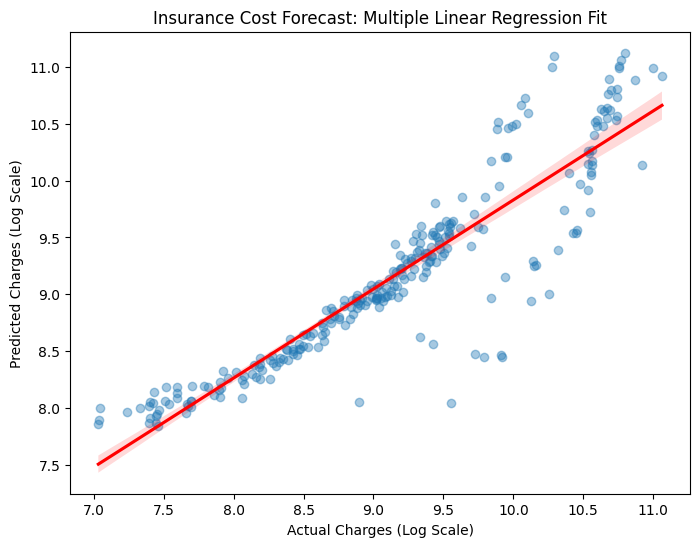

In [16]:
#Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.xlabel("Actual Charges (Log Scale)")
plt.ylabel("Predicted Charges (Log Scale)")
plt.title("Insurance Cost Forecast: Multiple Linear Regression Fit")
plt.show()

Rationale: This scatter plot with a 45-degree reference line was chosen to visually assess the model's accuracy and identify where the largest errors occur.

Interpretation: The model is highly accurate for lower-cost policies but tends to under-predict high-cost individuals (the fanning out effect), suggesting that the interaction between smoking and obesity is exponential rather than just additive.

--- Model Coefficients (Log Scale) ---
            Feature  Coefficient
4        smoker_yes     1.537330
2          children     0.099139
0               age     0.033990
1               bmi     0.013149
5  region_northwest    -0.043649
3          sex_male    -0.076769
7  region_southwest    -0.101224
6  region_southeast    -0.128562


/tmp/ipykernel_11958/3050370242.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')


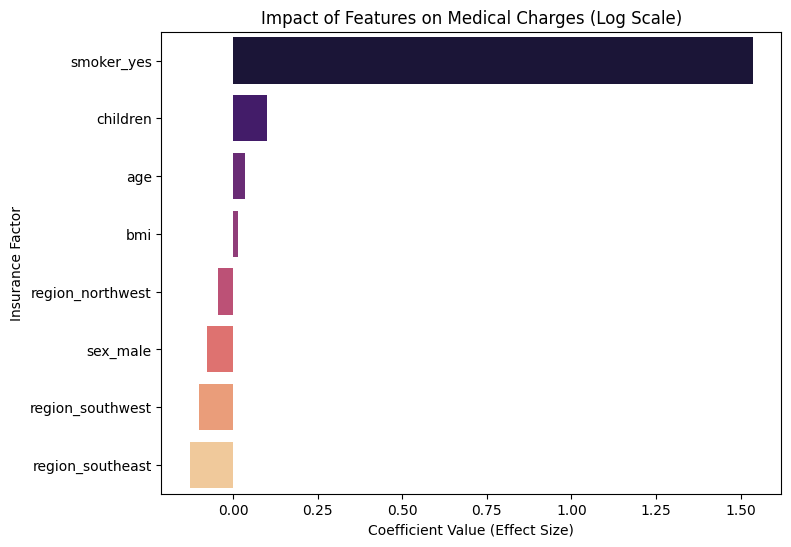

In [18]:
# Coefficient Analysis: Interpreting the Model

feature_names = X.columns
coefficients = model.coef_

# create a summary df
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("--- Model Coefficients (Log Scale) ---")
print(coef_df)

# visualize feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.title("Impact of Features on Medical Charges (Log Scale)")
plt.xlabel("Coefficient Value (Effect Size)")
plt.ylabel("Insurance Factor")
plt.show()

Rationale: I selected a Horizontal Bar Plot to visualize the regression coefficients because it allows for a clear, side-by-side comparison of how much influence each independent variable has on the target variable. By ranking the features from the most positive to the most negative impact, this visualization provides Explainable AI is essential in insurance context because it helps stakeholders instantly identify which factors—such as smoking or geographic region—drive the highest fluctuations in medical premiums.

Interpretation: As seen in the plot, smoker_yes is the dominant cost driver, indicating that smoking status has a massive multiplier effect on medical charges. Conversely, variables like region_southeast have negative coefficients, suggesting that being in those specific areas correlates with lower billed charges compared to the reference region.

Key Takeaways:

*   Dominant Cost Driver: Being a smoker is the most significant predictor by far, with a coefficient of 1.537, which translates to an exponential increase in billed charges compared to non-smokers.
*   Dependents and Age: Having children and increasing age follow as the next most positive drivers, where every additional child adds approximately 10% (e
0.099
 ) to the predicted base cost.

*   The BMI Factor: While BMI has a smaller coefficient of 0.013, it remains a steady upward pressure on premiums, likely interacting more severely with smoking status than the model shows alone.
*   Geographic Discounts: Being in the Northwest, Southwest, or Southeast regions actually correlates with lower charges compared to the Northeast region, as indicated by the negative coefficients.

In [23]:
# Convert Predictions back to Dollars

y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred)

from sklearn.metrics import mean_absolute_error
mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"On average, the model's prediction is off by: ${mae_dollars:.2f}")

# Create a comparison table for the first 10 test cases
comparison_df = pd.DataFrame({
    'Actual Charge ($)': y_test_dollars,
    'Predicted Charge ($)': y_pred_dollars,
    'Difference ($)': y_test_dollars - y_pred_dollars
}).head(10)

print("\n--- Sample Predictions ---")
print(comparison_df)

On average, the model's prediction is off by: $3755.92

--- Sample Predictions ---
      Actual Charge ($)  Predicted Charge ($)  Difference ($)
900          8688.85885           7609.558276     1079.300574
1064         5708.86700           5825.470883     -116.603883
1256        11436.73815          13603.895656    -2167.157506
298         38746.35510          28931.527470     9814.827630
237          4463.20510           5452.075579     -988.870479
481          9304.70190           9937.555814     -632.853914
240         38511.62830          23202.618683    15309.009617
277          2150.46900           3035.886984     -885.417984
415          7345.72660           7732.219027     -386.492427
707         10264.44210          10637.719935     -373.277835


While an average error of $3,755.92 is quite good for a dataset with such high variance, the visualization reveals a deeper story.The deeper story is that the dataset contains three distinct cost subpopulations (healthy non-smokers, smokers, and high-BMI smokers) that a single straight line cannot perfectly cut through.

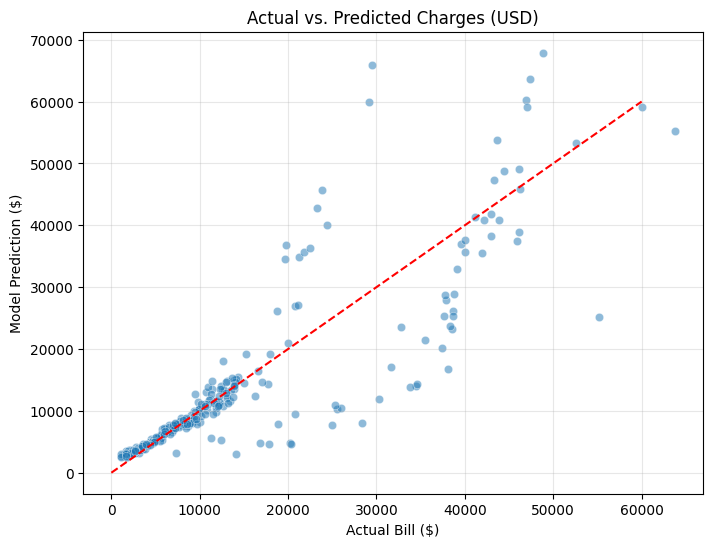

In [25]:
#visualize error in Dollars
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_dollars, y=y_pred_dollars, alpha=0.5)
plt.plot([0, 60000], [0, 60000], color='red', linestyle='--') # 45-degree line
plt.title("Actual vs. Predicted Charges (USD)")
plt.xlabel("Actual Bill ($)")
plt.ylabel("Model Prediction ($)")
plt.grid(True, alpha=0.3)
plt.show()

 Rationale: This scatter plot with a 45-degree reference line was chosen to visually assess the model's accuracy and identify where the largest errors occur.

 Interpretation: The plot shows that the model is extremely accurate for lower-cost policies (under $15,000), where the blue dots hug the red diagonal line tightly. This means that the model predicts costs for the average person well, it systematically underestimates high-risk individuals because the financial impact of smoking and obesity is exponential rather than additive.
However, as the actual bills increase, the points start to fan out and pull away from the line. The fanning out of scatter plot proves that while age drives steady growth, the true financial volatility is triggered by the interaction between lifestyle choices and biological markers.

Disclaimer: I used Google Gemini in the model selection process for this medical insurance cost forecasting project. The AI was used specifically to analyze the relationships between variables identified during the Exploratory Data Analysis (EDA) phase—such as the linear trend of age and the categorical cost bands created by smoking status—to determine which regression technique would offer the best balance of predictive accuracy and business interpretability.

Prompt Utilized:
"What type of regression model do you plan to use, and why is it appropriate for this data?"

Outcome & Rationalization:
Based on the AI’s analysis of the dataset's characteristics, Multiple Linear Regression (MLR) was selected as the optimal model. The AI helped clarify that MLR is superior for this task because it provides transparent, quantifiable coefficients for each risk factor (Age, BMI, Smoking), which is essential for justifying insurance premium adjustments in a professional context. While I authored the final project documentation and executed the code, the structural reasoning for choosing a linear approach over more complex "black box" models was informed by this AI-supported evaluation.